In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

Базовая обработка датасета

In [2]:
df = pd.read_csv("../data/2019_oct_dec.csv")

In [3]:
columns = ["event_time", "event_type", "product_id","category_id", "price", "user_id", "user_session"]
df = df[columns]

In [4]:
df["event_time"] = pd.to_datetime(df["event_time"])
df["year"] = df["event_time"].dt.year
df["month"] = df["event_time"].dt.month
df["day"] = df["event_time"].dt.day
df["hour"] = df["event_time"].dt.hour

In [5]:
df_oct = df[df["month"] == 10]
df_nov = df[df["month"] == 11]
df_dec = df[df["month"] == 12]

Найдём конверсию и построим воронку продаж на каждом этапе

In [6]:
event_types = ["view", "cart", "remove_from_cart", "purchase"]

In [ ]:
events_oct = [df_oct[df_oct["event_type"]==i]["user_id"].nunique() for i in event_types]
events_nov = [df_nov[df_nov["event_type"]==i]["user_id"].nunique() for i in event_types]
events_dec = [df_dec[df_dec["event_type"]==i]["user_id"].nunique() for i in event_types]

In [8]:
df_funnel = pd.DataFrame({
    "event_type": event_types * 3,
    "count": events_oct + events_nov + events_dec,
    'month': ['October']*len(events_oct) + 
             ['November']*len(events_nov) + 
             ['December']*len(events_dec)
})

C:\Users\s7omb\AppData\Local\Temp\ipykernel_9404\219929344.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  gr = sns.catplot(


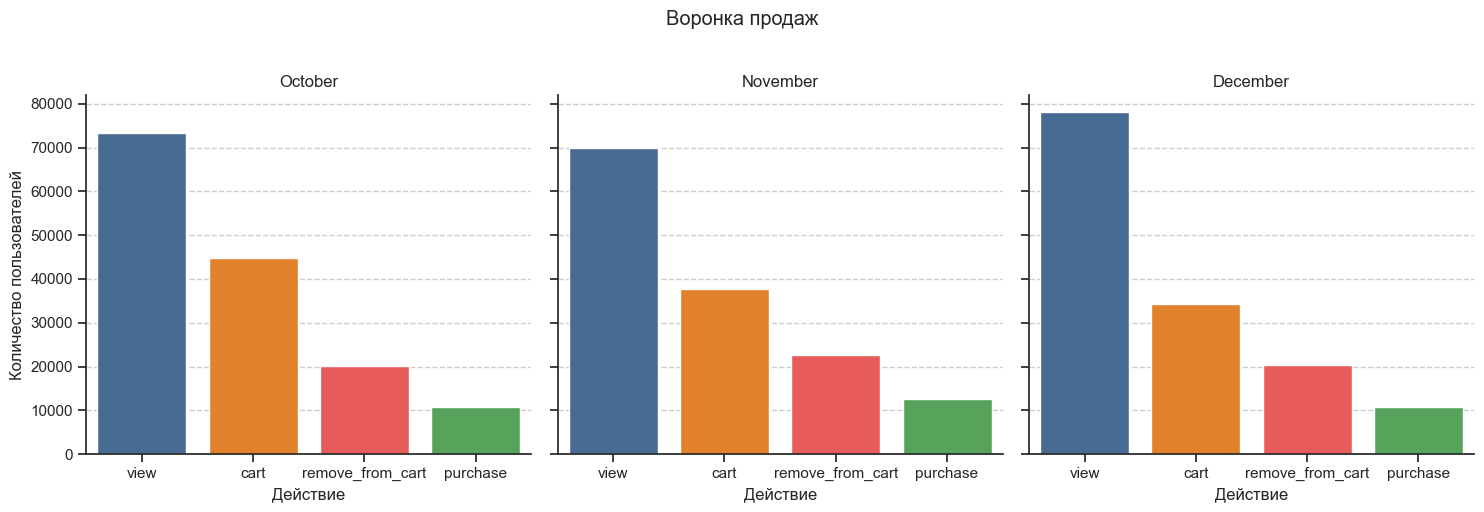

In [35]:
colors = ["#3A6BA0", "#FF7F0E", "#FF4444", "#4CAF50"]
palette = dict(zip(event_types, colors))


gr = sns.catplot(
    data = df_funnel,
    x = "event_type",
    y = "count",
    col = "month",
    palette = palette,
    kind = "bar",
    col_order = ["October", "November", "December"],
    sharey = True
)

for ax in gr.axes.flat:
    ax.yaxis.grid(True, alpha=1, linestyle='--')
    ax.set_axisbelow(True) 

gr.figure.suptitle("Воронка продаж",  y=1.02)
gr.set_axis_labels("Действие", "Количество пользователей")
gr.set_titles("{col_name}")

plt.tight_layout()
gr.savefig("../images/sales_funnel.png")

Конверсия в цифрах

In [13]:
conv_to_cart_oct = events_oct[1] / events_oct[0] * 100
conv_to_purchase_oct = events_oct[3] / events_oct[0] * 100
print("October conversion %")
print("----------------------------------------")
print(f"View → Cart: {conv_to_cart_oct:.1f}%")
print(f"View → Purchase: {conv_to_purchase_oct:.1f}%")
print("----------------------------------------")
print("Uncomplete purchase:")
conv_to_cart_oct = events_oct[2] / events_oct[1] * 100
print(f"Cart → Remove from cart: {conv_to_cart_oct:.1f}%")

October conversion %
----------------------------------------
View → Cart: 61.1%
View → Purchase: 14.6%
----------------------------------------
Uncomplete purchase:
Cart → Remove from cart: 45.1%


In [14]:
conv_to_cart_nov= events_nov[1] / events_nov[0] * 100
conv_to_purchase_nov = events_nov[3] / events_nov[0] * 100
print("November conversion %")
print("----------------------------------------")
print(f"View → Cart: {conv_to_cart_nov:.1f}%")
print(f"View → Purchase: {conv_to_purchase_nov:.1f}%")
print("----------------------------------------")
print("Uncomplete purchase:")
conv_to_cart_nov = events_nov[2] / events_nov[1] * 100
print(f"Cart → Remove from cart: {conv_to_cart_nov:.1f}%")

November conversion %
----------------------------------------
View → Cart: 54.0%
View → Purchase: 18.0%
----------------------------------------
Uncomplete purchase:
Cart → Remove from cart: 60.3%


In [15]:
conv_to_cart_dec = events_dec[1] / events_dec[0] * 100
conv_to_purchase_dec = events_dec[3] / events_dec[0] * 100
print("December conversion %")
print("-----------------------------------------------")
print(f"View → Cart: {conv_to_cart_dec:.1f}%")
print(f"View → Purchase: {conv_to_purchase_dec:.1f}%")
print("----------------------------------------")
print("Uncomplete purchase:")
conv_to_cart_dec = events_dec[2] / events_dec[1] * 100
print(f"Cart → Remove from cart: {conv_to_cart_dec:.1f}%")

December conversion %
-----------------------------------------------
View → Cart: 44.0%
View → Purchase: 13.8%
----------------------------------------
Uncomplete purchase:
Cart → Remove from cart: 59.0%


#### Выводы по воронке продаж

**Конверсия View -> Cart** снижается с октября по декабрь: 61% - 54% - 44%. Октябрь показывает наилучший результат, более половины пользователей, которые посмотрели товар добавили его в корзину.

**Конверсия View -> Purchase** варьируется в пределах ~15%. Пик - ноябрь (18%), может объясняться сезонными распродажами Black Friday.

**Незавершенные покупки** - ключевая проблема: 45-60% пользователей удаляют товар из корзины, не совершив покупку. В ноябре и декабре этот показатель максимален (59-60%). Может объясняться главным праздником в декабре (Рождеством), а также распродажами, когда люди добавляют больше чем нужно товаров в корзину, в качестве подарков, или вещей, которые давно хотели купить, и в итоге удаляют ненужное перед покупкой.

**Итог:** основная точка потери - этап cart -> purchase. Снижение конверсии к декабрю может указывать на сезонное изменение поведения или системные проблемы с оформлением заказа.

Средний чек за 3 месяца, и за каждый месяц поотдельности

In [37]:
sum_purchase = df[df["event_type"] == "purchase"]["price"].sum()
count_purchase = df[df["event_type"] == "purchase"].shape[0]
print(f"Средний чек за 3 месяца: {sum_purchase / count_purchase:.2f}$")

print("---------------------------------")

sum_purchase_oct = df[(df["event_type"] == "purchase") & (df["month"] == 10)]["price"].sum()
count_purchase_oct = df[(df["event_type"] == "purchase") & (df["month"] == 10)].shape[0]
print(f"Средний чек за октябрь: {sum_purchase_oct / count_purchase_oct:.2f}$")

sum_purchase_nov = df[(df["event_type"] == "purchase") & (df["month"] == 11)]["price"].sum()
count_purchase_nov = df[(df["event_type"] == "purchase") & (df["month"] == 11)].shape[0]
print(f"Средний чек за ноябрь: {sum_purchase_nov / count_purchase_nov:.2f}$")

sum_purchase_dec = df[(df["event_type"] == "purchase") & (df["month"] == 12)]["price"].sum()
count_purchase_dec = df[(df["event_type"] == "purchase") & (df["month"] == 12)].shape[0]
print(f"Средний чек за декабрь: {sum_purchase_dec / count_purchase_dec:.2f}$")


Средний чек за 3 месяца: 4.89$
---------------------------------
Средний чек за октябрь: 4.85$
Средний чек за ноябрь: 4.75$
Средний чек за декабрь: 5.08$


#### Выводы по средним чекам

- Средний чек за весь период и за каждый месяц отличаются в пределах ~0.20$.
- Пик приходится на декабрь (5.08$), что вероятно связано с увеличением числа покупок перед зимними праздниками.

**Итог:** средний чек за все рассмотренные месяцы стабилен, в среднем состовляет 4.9$.

Посмортрим на количество уникальных пользователей каждый день в течении месяца

In [17]:
unique_users_per_day = df.groupby(['year', 'month', 'day'])['user_id'].nunique().reset_index()
unique_users_per_day.columns = ['year', 'month', 'day', 'unique_users_count']

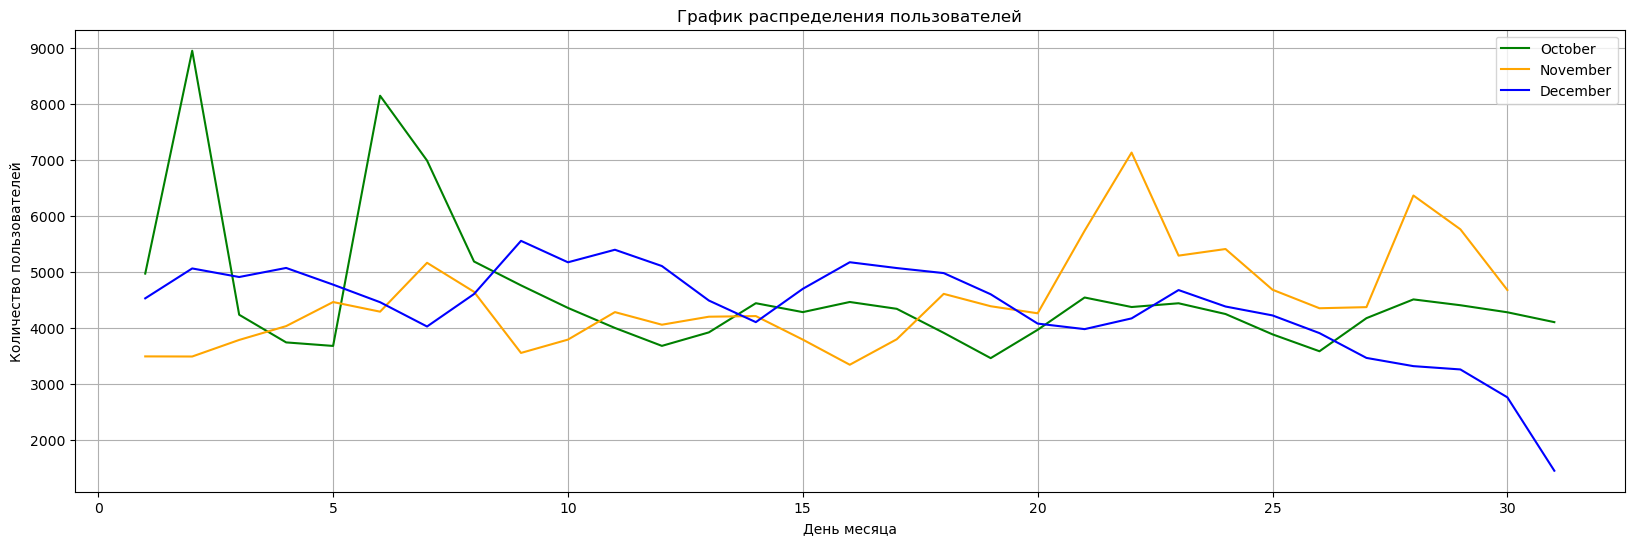

In [18]:
plt.figure(figsize = (20, 6))
plt.title("График распределения пользователей")
plt.xlabel("День месяца")
plt.ylabel("Количество пользователей") 
plt.grid()

plt.plot(
    unique_users_per_day[unique_users_per_day["month"] == 10]["day"], 
    unique_users_per_day[unique_users_per_day["month"] == 10]["unique_users_count"],
    label = "October",
    color = "green")


plt.plot(
    unique_users_per_day[unique_users_per_day["month"] == 11]["day"], 
    unique_users_per_day[unique_users_per_day["month"] == 11]["unique_users_count"],
    label = "November",
    color = "Orange")


plt.plot(
    unique_users_per_day[unique_users_per_day["month"] == 12]["day"],
    unique_users_per_day[unique_users_per_day["month"] == 12]["unique_users_count"],
    label = "December",
    color = "blue")

plt.legend()
plt.savefig("../images/users_distribution.png")

Узнаем топ 10 самых частых категорий товаров (в датасете они обезличены, есть только id)

In [19]:
category_purchase = df[df["event_type"] == "purchase"]
category_conversion = category_purchase.groupby("category_id")["price"].sum().reset_index(name="purchase_sum").sort_values("purchase_sum", ascending = False)

In [20]:
top_categories = category_conversion.nlargest(10, "purchase_sum")

<Figure size 1500x1500 with 0 Axes>

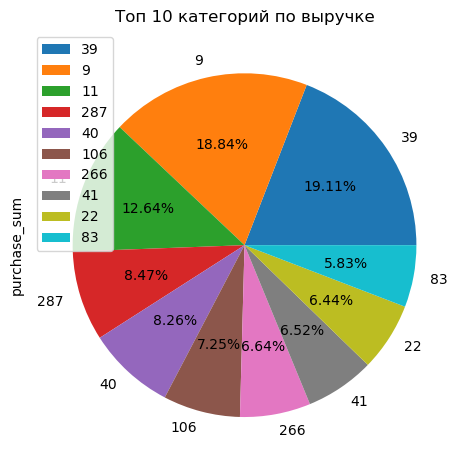

In [21]:
plt.figure(figsize=(15, 15))
top_categories.plot.pie(y = "purchase_sum",autopct='%.2f%%', title='Топ 10 категорий по выручке')
plt.tight_layout()
plt.savefig("../images/category_conversion.png")

Узнаем распределение количества совершенных покупок в зависимости от времени суток

In [22]:
morning_purchase = len(category_purchase[category_purchase["hour"].between(6, 12)])
day_purchase = len(category_purchase[category_purchase["hour"].between(13, 19)])
night_purchase = len(category_purchase[(category_purchase["hour"] >= 20) | (df["hour"] < 6) ])

phase_day = ["morning", "day", "night"]

df_phase_day = pd.Series([morning_purchase, day_purchase, night_purchase], index=phase_day)

C:\Users\s7omb\AppData\Local\Temp\ipykernel_9404\510597287.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  night_purchase = len(category_purchase[(category_purchase["hour"] >= 20) | (df["hour"] < 6) ])


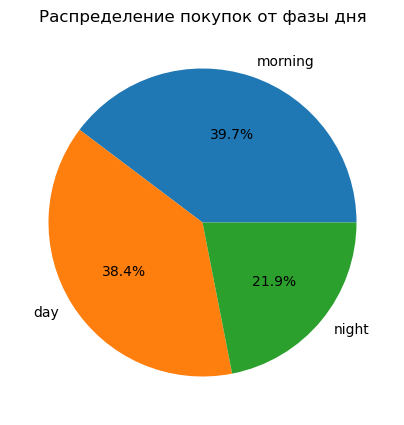

In [23]:
plt.figure(figsize = (5,5))
df_phase_day.plot.pie(y = "count", autopct='%1.1f%%', title = "Распределение покупок от фазы дня")
plt.savefig("../images/purchase_phase_day_distrib.png")

Среднее число сессий до покупки!!!